# Carregamento dos dados

In [ ]:
import os
import copy
import json
import time
import random
from pathlib import Path
#import yaml
import itertools
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


import sys
sys.path.append("C:/Users/loren/GNNGCN-proj/src")

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-05-31"

In [ ]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32

In [ ]:
catalog_dir = Path("C:/Users/loren/GNNGCN-proj") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


In [ ]:
base = "C:/Users/loren/GNNGCN-proj"
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"                                    # Início do período
end_date   = "2025-05-31"                                    # Fim do período
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_05-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "era5_vv_06-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações
 
 

In [ ]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

In [ ]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

In [ ]:
# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

In [ ]:
k = 61

In [ ]:
target_date = "2024-05-04"

# Matriz de adjacências dos vizinhos

In [ ]:
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# Cria uma matriz N x N preenchida com zeros
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

# Agregação por média

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
A_norm = torch.tensor(A / deg, dtype=torch.float32) 

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

n_idx = 32 # ID da estação (32 - Porto Alegre, Jardim Botânico)
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
epochs = 200 # Épocas
hidden = 2 # Número de neurônios na camada oculta
lr = 1e-3 # Taxa de aprendizado "eta".

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.10
p_test  = 0.20  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

Total de nós: 62
  Treino: 43  Val: 6  Teste: 13


# Montagem do grafo

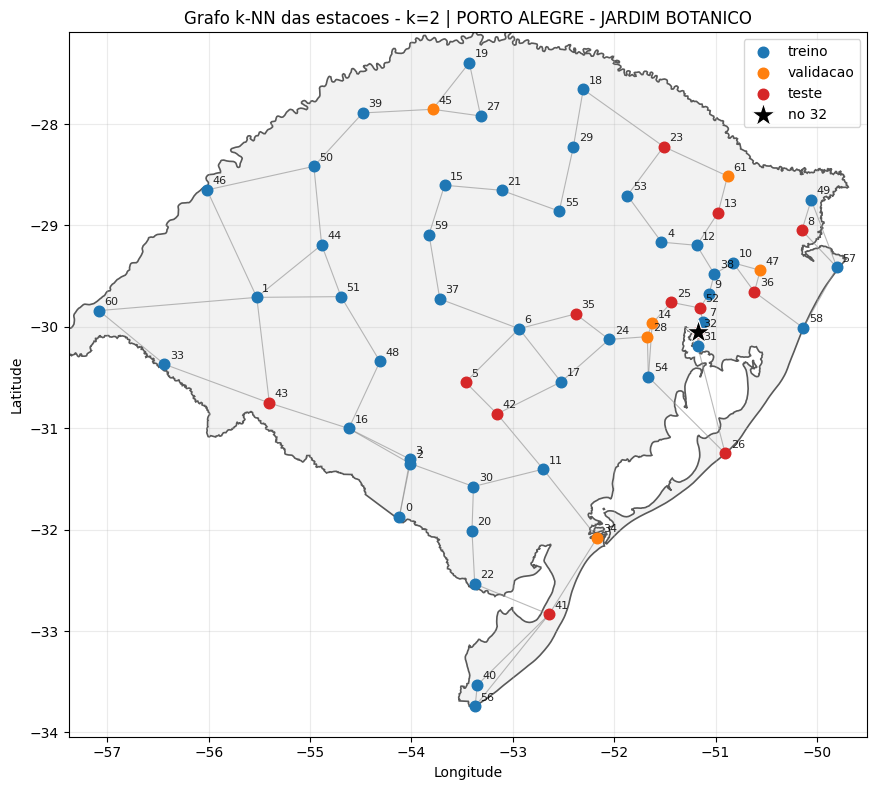

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=2:
  no   7 -> CACHOEIRINHA
  no  31 -> PORTO ALEGRE - BELEM NOVO


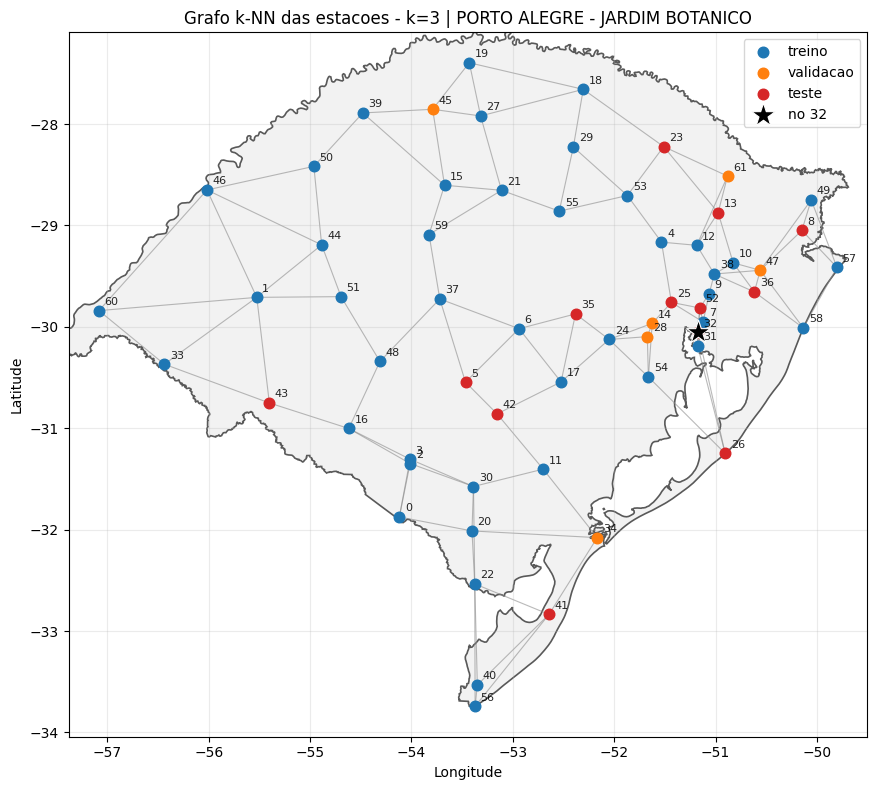

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=3:
  no   7 -> CACHOEIRINHA
  no  26 -> MOSTARDAS
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  52 -> SAPUCAIA DO SUL


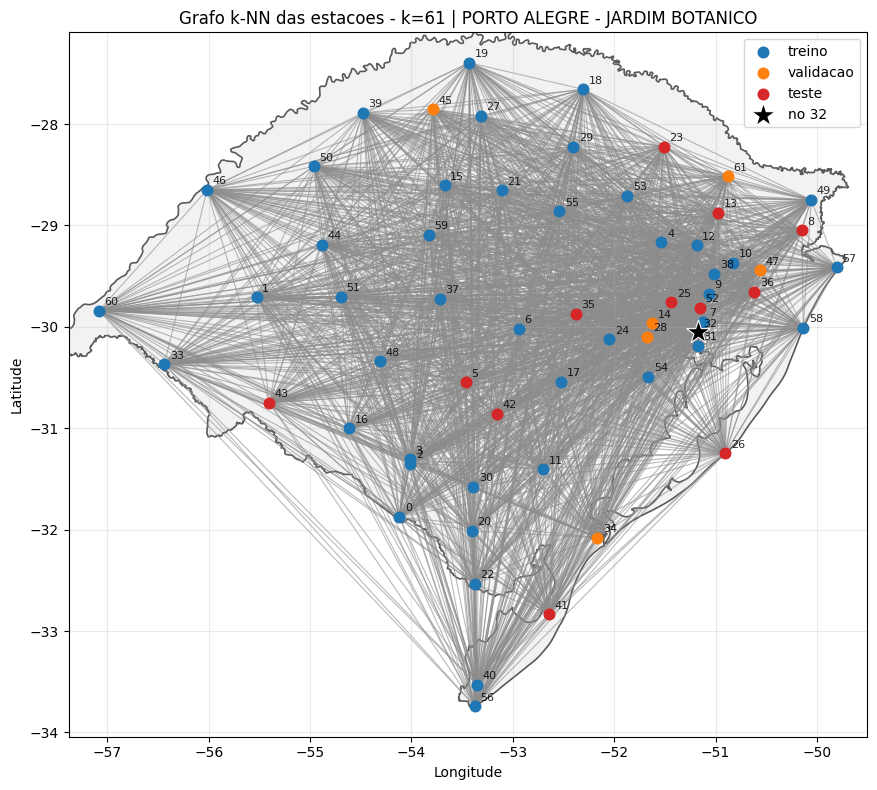

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=61:
  no   0 -> ACEGUA
  no   1 -> ALEGRETE
  no   2 -> BAGE
  no   3 -> BAGE - CENTRO
  no   4 -> BENTO GONCALVES
  no   5 -> CACAPAVA DO SUL
  no   6 -> CACHOEIRA DO SUL
  no   7 -> CACHOEIRINHA
  no   8 -> CAMBARA DO SUL
  no   9 -> CAMPO BOM
  no  10 -> CANELA
  no  11 -> CANGUCU
  no  12 -> CAXIAS DO SUL - AEROPORTO
  no  13 -> CAXIAS DO SUL - CRIUVA
  no  14 -> CHARQUEADAS
  no  15 -> CRUZ ALTA
  no  16 -> DOM PEDRITO
  no  17 -> ENCRUZILHADA DO SUL
  no  18 -> ERECHIM
  no  19 -> FREDERICO WESTPHALEN
  no  20 -> HERVAL
  no  21 -> IBIRUBA
  no  22 -> JAGUARAO
  no  23 -> LAGOA VERMELHA
  no  24 -> MINAS DO LEAO
  no  25 -> MONTENEGRO
  no  26 -> MOSTARDAS
  no  27 -> PALMEIRA DAS MISSOES
  no  28 -> PARQUE ELDORADO
  no  29 -> PASSO FUNDO
  no  30 -> PINHEIRO MACHADO
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  33 -> QUARAI
  no  34 -> RIO GRANDE
  no  35 -> RIO PARDO
  no  36 -> ROLANTE
  no  37 -> SANTA MARIA
  n

In [ ]:
import json
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

n_idx = 32  # Índice do nó para destacar (estação no índice 32)

def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        }
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    # Se vier compactado em gzip, descompacta antes de decodificar
    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=0
            )


def build_adjacency(coords, k=2, include_self=False):
    coords = np.asarray(coords, dtype=float)
    N = coords.shape[0]

    if k >= N:
        raise ValueError(f"k={k} precisa ser menor que o numero de nos N={N}.")

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A_bin = np.zeros((N, N), dtype=bool)

    for i in range(N):
        A_bin[i, idx[i]] = True

    A_bin = A_bin | A_bin.T

    if include_self:
        np.fill_diagonal(A_bin, True)
    else:
        np.fill_diagonal(A_bin, False)

    return A_bin


def as_numpy_mask(mask):
    if hasattr(mask, "detach"):
        return mask.detach().cpu().numpy().astype(bool)
    return np.asarray(mask, dtype=bool)


def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
                   mask_train=None, mask_val=None, mask_test=None,
                   figsize=(11, 8), label_nodes=True,
                   mapa_rs=None):

    coords = np.asarray(coords, dtype=float)
    A_bin = build_adjacency(coords, k=k, include_self=False)
    N = coords.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson(ax, mapa_rs)

    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="0.55",
                    linewidth=0.8,
                    alpha=0.6,
                    zorder=1,
                )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = as_numpy_mask(mask_train)
        val = as_numpy_mask(mask_val)
        test = as_numpy_mask(mask_test)

        ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
        ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
        ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
    else:
        ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

    ax.scatter(
        coords[n_idx, 1],
        coords[n_idx, 0],
        s=320,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        label=f"no {n_idx}",
        zorder=5,
    )

    if label_nodes:
        for i in range(N):
            ax.annotate(
                str(i),
                (coords[i, 1], coords[i, 0]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
                zorder=6,
            )

    vizinhos = np.where(A_bin[n_idx])[0]
    nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

    lon = coords[:, 1]
    lat = coords[:, 0]

    ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
    ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Vizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
    for j in vizinhos:
        nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
        print(f"  no {j:3d} -> {nome_vizinho}")

    return A_bin


mapa_rs = carregar_mapa_rs_ibge()

A_grafo2 = plot_knn_graph(coords, k=2, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo3 = plot_knn_graph(coords, k=3, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo61 = plot_knn_graph(coords, k=61, n_idx=n_idx, nomes=nomes,
                           mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                           figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

In [ ]:
n_hidden_layers = 12  # número de camadas ocultas do modelo

# Matriz com pesos nas arestas


In [ ]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def normalize_weighted_adjacency(A, eps=1e-12):
    """Normaliza pesos por linha."""
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.float32)
    else:
        A = A.float()

    degree = A.sum(dim=1, keepdim=True).clamp_min(eps)
    return A / degree


def normalize_weighted_adjacency_symmetric(A, eps=1e-12):
    """Normaliza pesos de forma simétrica."""
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.float32)
    else:
        A = A.float()

    degree = A.sum(dim=1, keepdim=True).clamp_min(eps)
    inv_sqrt_degree = 1.0 / torch.sqrt(degree)
    return A * inv_sqrt_degree * inv_sqrt_degree.t()


def make_weighted_adjacency_from_binary(
    A_base,
    edge_weights=None,
    default_edge_weight=1.0,
    self_loop_weight=1.0,
    symmetric=True,
    allow_new_edges=False,
    dtype=torch.float32,
    device=None,
):
    """Cria a matriz de adjacência ponderada a partir do grafo base."""
    if torch.is_tensor(A_base):
        if device is None:
            device = A_base.device
        A_np = A_base.detach().cpu().numpy()
    else:
        A_np = np.asarray(A_base)

    N = A_np.shape[0]

    topology = A_np > 0
    np.fill_diagonal(topology, False)

    if symmetric:
        topology = topology | topology.T

    A_weighted_np = np.zeros((N, N), dtype=np.float32)
    A_weighted_np[topology] = float(default_edge_weight)

    edge_weights = edge_weights or {}

    for (i, j), weight in edge_weights.items():
        i = int(i)
        j = int(j)
        weight = float(weight)

        if weight < 0:
            raise ValueError(f"Peso negativo nao permitido: ({i}, {j}) = {weight}")

        edge_exists = bool(topology[i, j] or (symmetric and topology[j, i]))

        if i != j and not edge_exists and not allow_new_edges:
            raise ValueError(
                f"A aresta ({i}, {j}) nao existe em A_base. "
                "Use allow_new_edges=True para cria-la."
            )

        A_weighted_np[i, j] = weight

        if symmetric:
            A_weighted_np[j, i] = weight

    np.fill_diagonal(A_weighted_np, float(self_loop_weight))

    if device is None:
        A_weighted = torch.tensor(A_weighted_np, dtype=dtype)
    else:
        A_weighted = torch.tensor(A_weighted_np, dtype=dtype, device=device)

    A_norm_weighted = normalize_weighted_adjacency_symmetric(A_weighted)

    return A_weighted, A_norm_weighted

In [ ]:
# =====================================================
# Pesos das arestas: exp(-||x_i - x_j||)
# =====================================================

coords_tensor = torch.tensor(coords, dtype=torch.float32)  # coordenadas das estações

dist_matrix = torch.cdist(coords_tensor, coords_tensor, p=2)  # matriz de distâncias euclidianas

edge_mask = torch.tensor(A, dtype=torch.float32) > 0  # máscara das arestas do grafo
edge_mask.fill_diagonal_(False)

edge_weight_matrix = torch.exp(-dist_matrix)  # pesos mais altos para nós mais próximos

edge_weights = {
    (int(i), int(j)): float(edge_weight_matrix[i, j])
    for i, j in edge_mask.nonzero(as_tuple=False)
}

In [ ]:
A_weighted, A_norm_weighted = make_weighted_adjacency_from_binary(
    A_base=A,  # matriz binária do grafo
    edge_weights=edge_weights,  # pesos das arestas por distância
    default_edge_weight=1.0,  # peso padrão para arestas sem informação explícita
    self_loop_weight=1.0,  # peso do auto-loop
    symmetric=True,  # grafo tratado como não direcionado
    allow_new_edges=False,
)

A_norm = A_norm_weighted  # matriz de adjacência normalizada usada no modelo


# =====================================================
# Modelo GNN com arestas ponderadas
# =====================================================

class WeightedGNN(nn.Module):
    """GNN simples com propagação ponderada pelo grafo."""
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=6, out_dim=1):
        super().__init__()

        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(nn.Linear(in_dim, hidden_dim))  # camada de entrada

        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))  # camadas ocultas

        self.W_out = nn.Linear(hidden_dim, out_dim)  # camada de saída

    def forward(self, X, A_norm_weighted):
        """Propaga informações pelo grafo e gera a predição."""
        H = X  # features dos nós

        for layer in self.hidden_layers:
            H = A_norm_weighted @ H  # agregação com o grafo
            H = F.relu(layer(H))  # ativação não linear

        out = self.W_out(H)
        return out.squeeze(-1)


modelo = WeightedGNN(
    in_dim=F_in,  # dimensão das features de entrada
    hidden_dim=hidden,  # tamanho da camada oculta
    n_hidden_layers=n_hidden_layers,  # número de camadas ocultas
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)  # otimização do modelo
loss_fn = nn.MSELoss()  # função de erro quadrático médio

print("A_weighted shape:", tuple(A_weighted.shape))
print("A_norm_weighted shape:", tuple(A_norm_weighted.shape))
print("Soma das primeiras linhas:", A_norm_weighted.sum(dim=1)[:5])

A_weighted shape: (62, 62)
A_norm_weighted shape: (62, 62)
Soma das primeiras linhas: tensor([0.9548, 0.9428, 1.0283, 1.0303, 1.0757])


In [ ]:
print(A_weighted)

tensor([[1.0000, 0.0756, 0.5841,  ..., 0.0608, 0.0275, 0.0094],
        [0.0756, 1.0000, 0.1075,  ..., 0.1639, 0.2097, 0.0083],
        [0.5841, 0.1075, 1.0000,  ..., 0.1037, 0.0327, 0.0147],
        ...,
        [0.0608, 0.1639, 0.1037,  ..., 1.0000, 0.0354, 0.0498],
        [0.0275, 0.2097, 0.0327,  ..., 0.0354, 1.0000, 0.0018],
        [0.0094, 0.0083, 0.0147,  ..., 0.0498, 0.0018, 1.0000]])


In [ ]:
print(A_norm_weighted)

tensor([[1.3878e-01, 1.1637e-02, 7.3211e-02,  ..., 7.5084e-03, 5.9946e-03,
         1.1080e-03],
        [1.1637e-02, 1.7057e-01, 1.4943e-02,  ..., 2.2453e-02, 5.0700e-02,
         1.0808e-03],
        [7.3211e-02, 1.4943e-02, 1.1319e-01,  ..., 1.1572e-02, 6.4475e-03,
         1.5588e-03],
        ...,
        [7.5084e-03, 2.2453e-02, 1.1572e-02,  ..., 1.0998e-01, 6.8736e-03,
         5.2215e-03],
        [5.9946e-03, 5.0700e-02, 6.4475e-03,  ..., 6.8736e-03, 3.4256e-01,
         3.2662e-04],
        [1.1080e-03, 1.0808e-03, 1.5588e-03,  ..., 5.2215e-03, 3.2662e-04,
         9.9945e-02]])


# Pesos nas arestas

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd


def build_edge_weights_table(A_weighted, A_norm_weighted=None, nomes=None, directed=False):
    if hasattr(A_weighted, "detach"):
        W = A_weighted.detach().cpu().numpy()
    else:
        W = np.asarray(A_weighted, dtype=float)

    if A_norm_weighted is not None:
        if hasattr(A_norm_weighted, "detach"):
            W_norm = A_norm_weighted.detach().cpu().numpy()
        else:
            W_norm = np.asarray(A_norm_weighted, dtype=float)
    else:
        W_norm = None

    rows = []
    N = W.shape[0]

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            if not directed and i > j:
                continue

            if W[i, j] <= 0:
                continue

            row = {
                "no_i": i,
                "no_j": j,
                "peso_bruto": W[i, j],
            }

            if nomes is not None:
                row["estacao_i"] = nomes[i]
                row["estacao_j"] = nomes[j]

            if W_norm is not None:
                row["peso_normalizado_i_para_j"] = W_norm[i, j]

                if not directed:
                    row["peso_normalizado_j_para_i"] = W_norm[j, i]

            rows.append(row)

    df_weights = pd.DataFrame(rows)

    if not df_weights.empty:
        df_weights = df_weights.sort_values(
            ["no_i", "no_j"],
            ascending=True,
        ).reset_index(drop=True)

    return df_weights


df_edge_weights = build_edge_weights_table(
    A_weighted,
    A_norm_weighted=A_norm_weighted,
    nomes=nomes,
    directed=False,
)

display(df_edge_weights)

,no_i,no_j,peso_bruto,estacao_i,estacao_j,peso_normalizado_i_para_j,peso_normalizado_j_para_i
0,0,1,0.075633,ACEGUA,ALEGRETE,0.011637,0.011637
1,0,2,0.584122,ACEGUA,BAGE,0.073211,0.073211
2,0,3,0.560358,ACEGUA,BAGE - CENTRO,0.070006,0.070006
3,0,4,0.023619,ACEGUA,BENTO GONCALVES,0.002396,0.002396
4,0,5,0.227410,ACEGUA,CACAPAVA DO SUL,0.026609,0.026609
...,...,...,...,...,...,...,...
1886,58,60,0.000960,TRAMANDAI,URUGUAIANA,0.000186,0.000186
1887,58,61,0.187744,TRAMANDAI,VACARIA,0.019630,0.019630
1888,59,60,0.035413,TUPANCIRETA,URUGUAIANA,0.006874,0.006874
1889,59,61,0.049803,TUPANCIRETA,VACARIA,0.005222,0.005222


# Modelo utilizando pesos nas arestas

In [ ]:
import copy
import itertools
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML, Latex


# Treina o modelo ponderado para uma configuração fixa.
# X_in = features dos nós, y_all = alvo dos nós, A_norm_weighted = grafo usado na propagação.
def run_experiment_weighted(epochs, hidden, n_hidden_layers, X_in, y_all, A_norm_weighted,
                            mask_train, mask_val, mask_test,
                            F_in=2, lr=1e-3, n_idx=32, seed=42,
                            patience=20, min_delta=1e-5):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Modelo, otimizador e função de perda.
    modelo = WeightedGNN(
        in_dim=F_in,
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers
    )

    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Histórico das perdas para acompanhar treino e validação.
    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    # Melhor estado salvo para evitar overfitting.
    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    # Treino por épocas e avaliação em cada passo.
    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_norm_weighted)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_norm_weighted)
            loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])
            loss_test = loss_fn(y_pred_eval[mask_test], y_all[mask_test])

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

    # Carrega o melhor estado encontrado.
    modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_norm_weighted)

        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()
        pred_no      = y_pred_all[n_idx].item()
        true_no      = y_all[n_idx].item()

    return {
        "epochs": epochs,
        "hidden": hidden,
        "n_hidden_layers": n_hidden_layers,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "loss_train": loss_train_f,
        "loss_val": loss_val_f,
        "loss_test": loss_test_f,
        "pred": pred_no,
        "true": true_no,
        "historico": historico,
    }

In [ ]:
# Grade de valores testados para k, épocas e tamanho oculto.
# Cada configuração gera um resultado diferente do modelo.
k_grid = [2, 3, 61]
epochs_grid = [100, 200, 400, 500, 1000]
hidden_grid = [2, 6, 12, 24, 48]

# Pasta para salvar tabelas e arquivos de saída.
output_dir = Path("../Results_WGNN")
output_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")

# Pesos das arestas baseados na distância entre estações.
coords_tensor = torch.tensor(coords, dtype=torch.float32)
dist_matrix = torch.cdist(coords_tensor, coords_tensor, p=2)
edge_weight_matrix = torch.exp(-dist_matrix)

# Armazena os resultados de todas as execuções.
resultados_weighted_todos = []
historicos_weighted = {}
paradas_weighted = {}
dfs_weighted_por_k = {}

# Para cada valor de k, cria um grafo e roda o experimento.
for k_atual in k_grid:
    print(f"\n===== Rodando Weighted GNN para K={k_atual} =====")

    # Grafo binário para o valor atual de k.
    A_k = build_adjacency(coords, k=k_atual, include_self=False)

    # Máscara das arestas com pesos para este grafo.
    edge_mask = torch.tensor(A_k, dtype=torch.float32) > 0
    edge_mask.fill_diagonal_(False)

    # Dicionário de pesos por aresta.
    edge_weights = {
        (int(i), int(j)): float(edge_weight_matrix[i, j])
        for i, j in edge_mask.nonzero(as_tuple=False)
    }

    # Matriz ponderada e sua versão normalizada para o modelo.
    A_weighted_k, A_norm_weighted_k = make_weighted_adjacency_from_binary(
        A_base=A_k,
        edge_weights=edge_weights,
        default_edge_weight=1.0,
        self_loop_weight=1.0,
        symmetric=True,
        allow_new_edges=False,
    )

    resultados_weighted_k = []

    # Testa combinações de épocas e tamanho oculto.
    for ep, hd in itertools.product(epochs_grid, hidden_grid):
        print(f"Rodando Weighted GNN K={k_atual}, epochs={ep}, hidden={hd}...")

        # Executa uma rodada com os dados e o grafo atuais.
        r = run_experiment_weighted(
            epochs=ep,
            hidden=hd,
            n_hidden_layers=n_hidden_layers,
            X_in=X_in,
            y_all=y_all,
            A_norm_weighted=A_norm_weighted_k,
            mask_train=mask_train,
            mask_val=mask_val,
            mask_test=mask_test,
            F_in=F_in,
            lr=lr,
            n_idx=n_idx,
            seed=SEED,
            patience=60,
            min_delta=1e-4
        )

        # Guarda histórico e parada para cada configuração.
        historicos_weighted[(k_atual, ep, hd)] = r["historico"]
        paradas_weighted[(k_atual, ep, hd)] = r["stop_epoch"]

        r_sem_historico = r.copy()
        del r_sem_historico["historico"]
        r_sem_historico["k"] = k_atual

        resultados_weighted_k.append(r_sem_historico)
        resultados_weighted_todos.append(r_sem_historico)

    # Tabela para cada valor de k.
    df_weighted_k = pd.DataFrame(resultados_weighted_k)
    dfs_weighted_por_k[k_atual] = df_weighted_k

    print(df_weighted_k)

    output_csv_path = output_dir / f"WeightedGNNResults-K{k_atual}-HL{n_hidden_layers}-D{target_date_file}.csv"
    output_tex_path = output_dir / f"WeightedGNNResults-K{k_atual}-HL{n_hidden_layers}-D{target_date_file}.tex"

    df_weighted_k.to_csv(output_csv_path, index=False)

    df_weighted_k.to_latex(
        output_tex_path,
        index=False,
        float_format="%.6f",
        caption=f"Resultados da Weighted GNN para K={k_atual}",
        label=f"tab:weighted_gnn_results_k{k_atual}",
        escape=True,
    )

    print(f"Arquivo CSV salvo em: {output_csv_path}")
    print(f"Arquivo TeX salvo em: {output_tex_path}")

    # Exibe a tabela de forma visível no notebook.
    display(HTML(f"<h4>Tabela para K={k_atual}</h4>"))
    display(df_weighted_k)
    display(HTML(df_weighted_k.to_html(index=False, escape=False)))
    if output_tex_path.exists():
        display(Latex(output_tex_path.read_text(encoding="utf-8")))
    else:
        print("Arquivo TeX ainda não foi gerado.")


# Tabela consolidada com todos os resultados.
df_weighted_todos = pd.DataFrame(resultados_weighted_todos)

output_csv_all_path = output_dir / f"WeightedGNNResults-AllK-HL{n_hidden_layers}-D{target_date_file}.csv"
output_tex_all_path = output_dir / f"WeightedGNNResults-AllK-HL{n_hidden_layers}-D{target_date_file}.tex"

df_weighted_todos.to_csv(output_csv_all_path, index=False)

df_weighted_todos.to_latex(
    output_tex_all_path,
    index=False,
    float_format="%.6f",
    caption="Resultados da Weighted GNN para diferentes valores de K",
    label="tab:weighted_gnn_results_all_k",
    escape=True,
)

print("\n===== Resultados consolidados =====")
print(df_weighted_todos)
print(f"Arquivo CSV consolidado salvo em: {output_csv_all_path}")
print(f"Arquivo TeX consolidado salvo em: {output_tex_all_path}")

# Exibe a tabela final de forma clara.
display(HTML("<h4>Tabela consolidada</h4>"))
display(df_weighted_todos)
display(HTML(df_weighted_todos.to_html(index=False, escape=False)))
if output_tex_all_path.exists():
    display(Latex(output_tex_all_path.read_text(encoding="utf-8")))
else:
    print("Arquivo TeX consolidado ainda não foi gerado.")


===== Rodando Weighted GNN para K=2 =====
Rodando Weighted GNN K=2, epochs=100, hidden=2...
Rodando Weighted GNN K=2, epochs=100, hidden=6...
Rodando Weighted GNN K=2, epochs=100, hidden=12...
Rodando Weighted GNN K=2, epochs=100, hidden=24...
Rodando Weighted GNN K=2, epochs=100, hidden=48...
Rodando Weighted GNN K=2, epochs=200, hidden=2...
Rodando Weighted GNN K=2, epochs=200, hidden=6...
Rodando Weighted GNN K=2, epochs=200, hidden=12...
Rodando Weighted GNN K=2, epochs=200, hidden=24...
Rodando Weighted GNN K=2, epochs=200, hidden=48...
Rodando Weighted GNN K=2, epochs=400, hidden=2...
Rodando Weighted GNN K=2, epochs=400, hidden=6...
Rodando Weighted GNN K=2, epochs=400, hidden=12...
Rodando Weighted GNN K=2, epochs=400, hidden=24...
Rodando Weighted GNN K=2, epochs=400, hidden=48...
Rodando Weighted GNN K=2, epochs=500, hidden=2...
Rodando Weighted GNN K=2, epochs=500, hidden=6...
Rodando Weighted GNN K=2, epochs=500, hidden=12...
Rodando Weighted GNN K=2, epochs=500, hidden=24


===== Rodando Weighted GNN para K=2 =====
Rodando Weighted GNN K=2, epochs=100, hidden=2...
Rodando Weighted GNN K=2, epochs=100, hidden=6...
Rodando Weighted GNN K=2, epochs=100, hidden=12...
Rodando Weighted GNN K=2, epochs=100, hidden=24...
Rodando Weighted GNN K=2, epochs=100, hidden=48...
Rodando Weighted GNN K=2, epochs=200, hidden=2...
Rodando Weighted GNN K=2, epochs=200, hidden=6...
Rodando Weighted GNN K=2, epochs=200, hidden=12...
Rodando Weighted GNN K=2, epochs=200, hidden=24...
Rodando Weighted GNN K=2, epochs=200, hidden=48...
Rodando Weighted GNN K=2, epochs=400, hidden=2...
Rodando Weighted GNN K=2, epochs=400, hidden=6...
Rodando Weighted GNN K=2, epochs=400, hidden=12...
Rodando Weighted GNN K=2, epochs=400, hidden=24...
Rodando Weighted GNN K=2, epochs=400, hidden=48...
Rodando Weighted GNN K=2, epochs=500, hidden=2...
Rodando Weighted GNN K=2, epochs=500, hidden=6...
Rodando Weighted GNN K=2, epochs=500, hidden=12...
Rodando Weighted GNN K=2, epochs=500, hidden=24


===== Rodando Weighted GNN para K=2 =====
Rodando Weighted GNN K=2, epochs=100, hidden=2...
Rodando Weighted GNN K=2, epochs=100, hidden=6...
Rodando Weighted GNN K=2, epochs=100, hidden=12...
Rodando Weighted GNN K=2, epochs=100, hidden=24...
Rodando Weighted GNN K=2, epochs=100, hidden=48...
Rodando Weighted GNN K=2, epochs=200, hidden=2...
Rodando Weighted GNN K=2, epochs=200, hidden=6...
Rodando Weighted GNN K=2, epochs=200, hidden=12...
Rodando Weighted GNN K=2, epochs=200, hidden=24...
Rodando Weighted GNN K=2, epochs=200, hidden=48...
Rodando Weighted GNN K=2, epochs=400, hidden=2...
Rodando Weighted GNN K=2, epochs=400, hidden=6...
Rodando Weighted GNN K=2, epochs=400, hidden=12...
Rodando Weighted GNN K=2, epochs=400, hidden=24...
Rodando Weighted GNN K=2, epochs=400, hidden=48...
Rodando Weighted GNN K=2, epochs=500, hidden=2...
Rodando Weighted GNN K=2, epochs=500, hidden=6...
Rodando Weighted GNN K=2, epochs=500, hidden=12...
Rodando Weighted GNN K=2, epochs=500, hidden=24

,epochs,hidden,n_hidden_layers,best_epoch,stop_epoch,loss_train,loss_val,loss_test,pred,true,k
0,100,2,12,100,100,1573.289917,1207.594604,1355.700928,0.212451,35.327911,2
1,100,6,12,100,100,1567.855591,1202.095703,1350.440063,0.313690,35.327911,2
2,100,12,12,95,100,636.872498,247.041550,454.633148,31.572350,35.327911,2
3,100,24,12,91,100,635.109985,246.133316,451.948395,31.584768,35.327911,2
4,100,48,12,92,100,632.626526,244.915237,448.114410,31.436020,35.327911,2
5,200,2,12,200,200,1535.556641,1169.026367,1319.479126,0.828627,35.327911,2
6,200,6,12,200,200,1561.856445,1195.977905,1344.669800,0.413420,35.327911,2
7,200,12,12,145,200,637.103271,246.893173,454.744141,31.219595,35.327911,2
8,200,24,12,129,189,634.945435,246.025635,451.778931,31.519722,35.327911,2
9,200,48,12,92,152,632.626526,244.915237,448.114410,31.436020,35.327911,2


epochs,hidden,n_hidden_layers,best_epoch,stop_epoch,loss_train,loss_val,loss_test,pred,true,k
100,2,12,100,100,1573.289917,1207.594604,1355.700928,0.212451,35.327911,2
100,6,12,100,100,1567.855591,1202.095703,1350.440063,0.313690,35.327911,2
100,12,12,95,100,636.872498,247.041550,454.633148,31.572350,35.327911,2
100,24,12,91,100,635.109985,246.133316,451.948395,31.584768,35.327911,2
100,48,12,92,100,632.626526,244.915237,448.114410,31.436020,35.327911,2
200,2,12,200,200,1535.556641,1169.026367,1319.479126,0.828627,35.327911,2
200,6,12,200,200,1561.856445,1195.977905,1344.669800,0.413420,35.327911,2
200,12,12,145,200,637.103271,246.893173,454.744141,31.219595,35.327911,2
200,24,12,129,189,634.945435,246.025635,451.778931,31.519722,35.327911,2
200,48,12,92,152,632.626526,244.915237,448.114410,31.436020,35.327911,2


...

<IPython.core.display.Latex object>


===== Resultados consolidados =====
    epochs  hidden  n_hidden_layers  best_epoch  stop_epoch   loss_train  \
0      100       2               12         100         100  1573.289917   
1      100       6               12         100         100  1567.855591   
2      100      12               12          95         100   636.872498   
3      100      24               12          91         100   635.109985   
4      100      48               12          92         100   632.626526   
..     ...     ...              ...         ...         ...          ...   
70    1000       2               12         880         940   604.419983   
71    1000       6               12        1000        1000  1514.862427   
72    1000      12               12         118         178   563.023193   
73    1000      24               12          90         150   563.153320   
74    1000      48               12          59         119   560.417603   

       loss_val    loss_test       pred       true

,epochs,hidden,n_hidden_layers,best_epoch,stop_epoch,loss_train,loss_val,loss_test,pred,true,k
0,100,2,12,100,100,1573.289917,1207.594604,1355.700928,0.212451,35.327911,2
1,100,6,12,100,100,1567.855591,1202.095703,1350.440063,0.313690,35.327911,2
2,100,12,12,95,100,636.872498,247.041550,454.633148,31.572350,35.327911,2
3,100,24,12,91,100,635.109985,246.133316,451.948395,31.584768,35.327911,2
4,100,48,12,92,100,632.626526,244.915237,448.114410,31.436020,35.327911,2
...,...,...,...,...,...,...,...,...,...,...,...
70,1000,2,12,880,940,604.419983,232.580643,429.084167,34.961040,35.327911,61
71,1000,6,12,1000,1000,1514.862427,1148.038330,1299.497925,1.206449,35.327911,61
72,1000,12,12,118,178,563.023193,220.982620,375.127930,36.435242,35.327911,61
73,1000,24,12,90,150,563.153320,220.689941,373.926117,36.246231,35.327911,61


epochs,hidden,n_hidden_layers,best_epoch,stop_epoch,loss_train,loss_val,loss_test,pred,true,k
100,2,12,100,100,1573.289917,1207.594604,1355.700928,0.212451,35.327911,2
100,6,12,100,100,1567.855591,1202.095703,1350.440063,0.313690,35.327911,2
100,12,12,95,100,636.872498,247.041550,454.633148,31.572350,35.327911,2
100,24,12,91,100,635.109985,246.133316,451.948395,31.584768,35.327911,2
100,48,12,92,100,632.626526,244.915237,448.114410,31.436020,35.327911,2
200,2,12,200,200,1535.556641,1169.026367,1319.479126,0.828627,35.327911,2
200,6,12,200,200,1561.856445,1195.977905,1344.669800,0.413420,35.327911,2
200,12,12,145,200,637.103271,246.893173,454.744141,31.219595,35.327911,2
200,24,12,129,189,634.945435,246.025635,451.778931,31.519722,35.327911,2
200,48,12,92,152,632.626526,244.915237,448.114410,31.436020,35.327911,2


<IPython.core.display.Latex object>


===== Gerando gráficos para K=2 =====
Grafico salvo em: ..\Graphics_WGNN\WeightedGNNGraphics-K2-HL12-D20240504.png


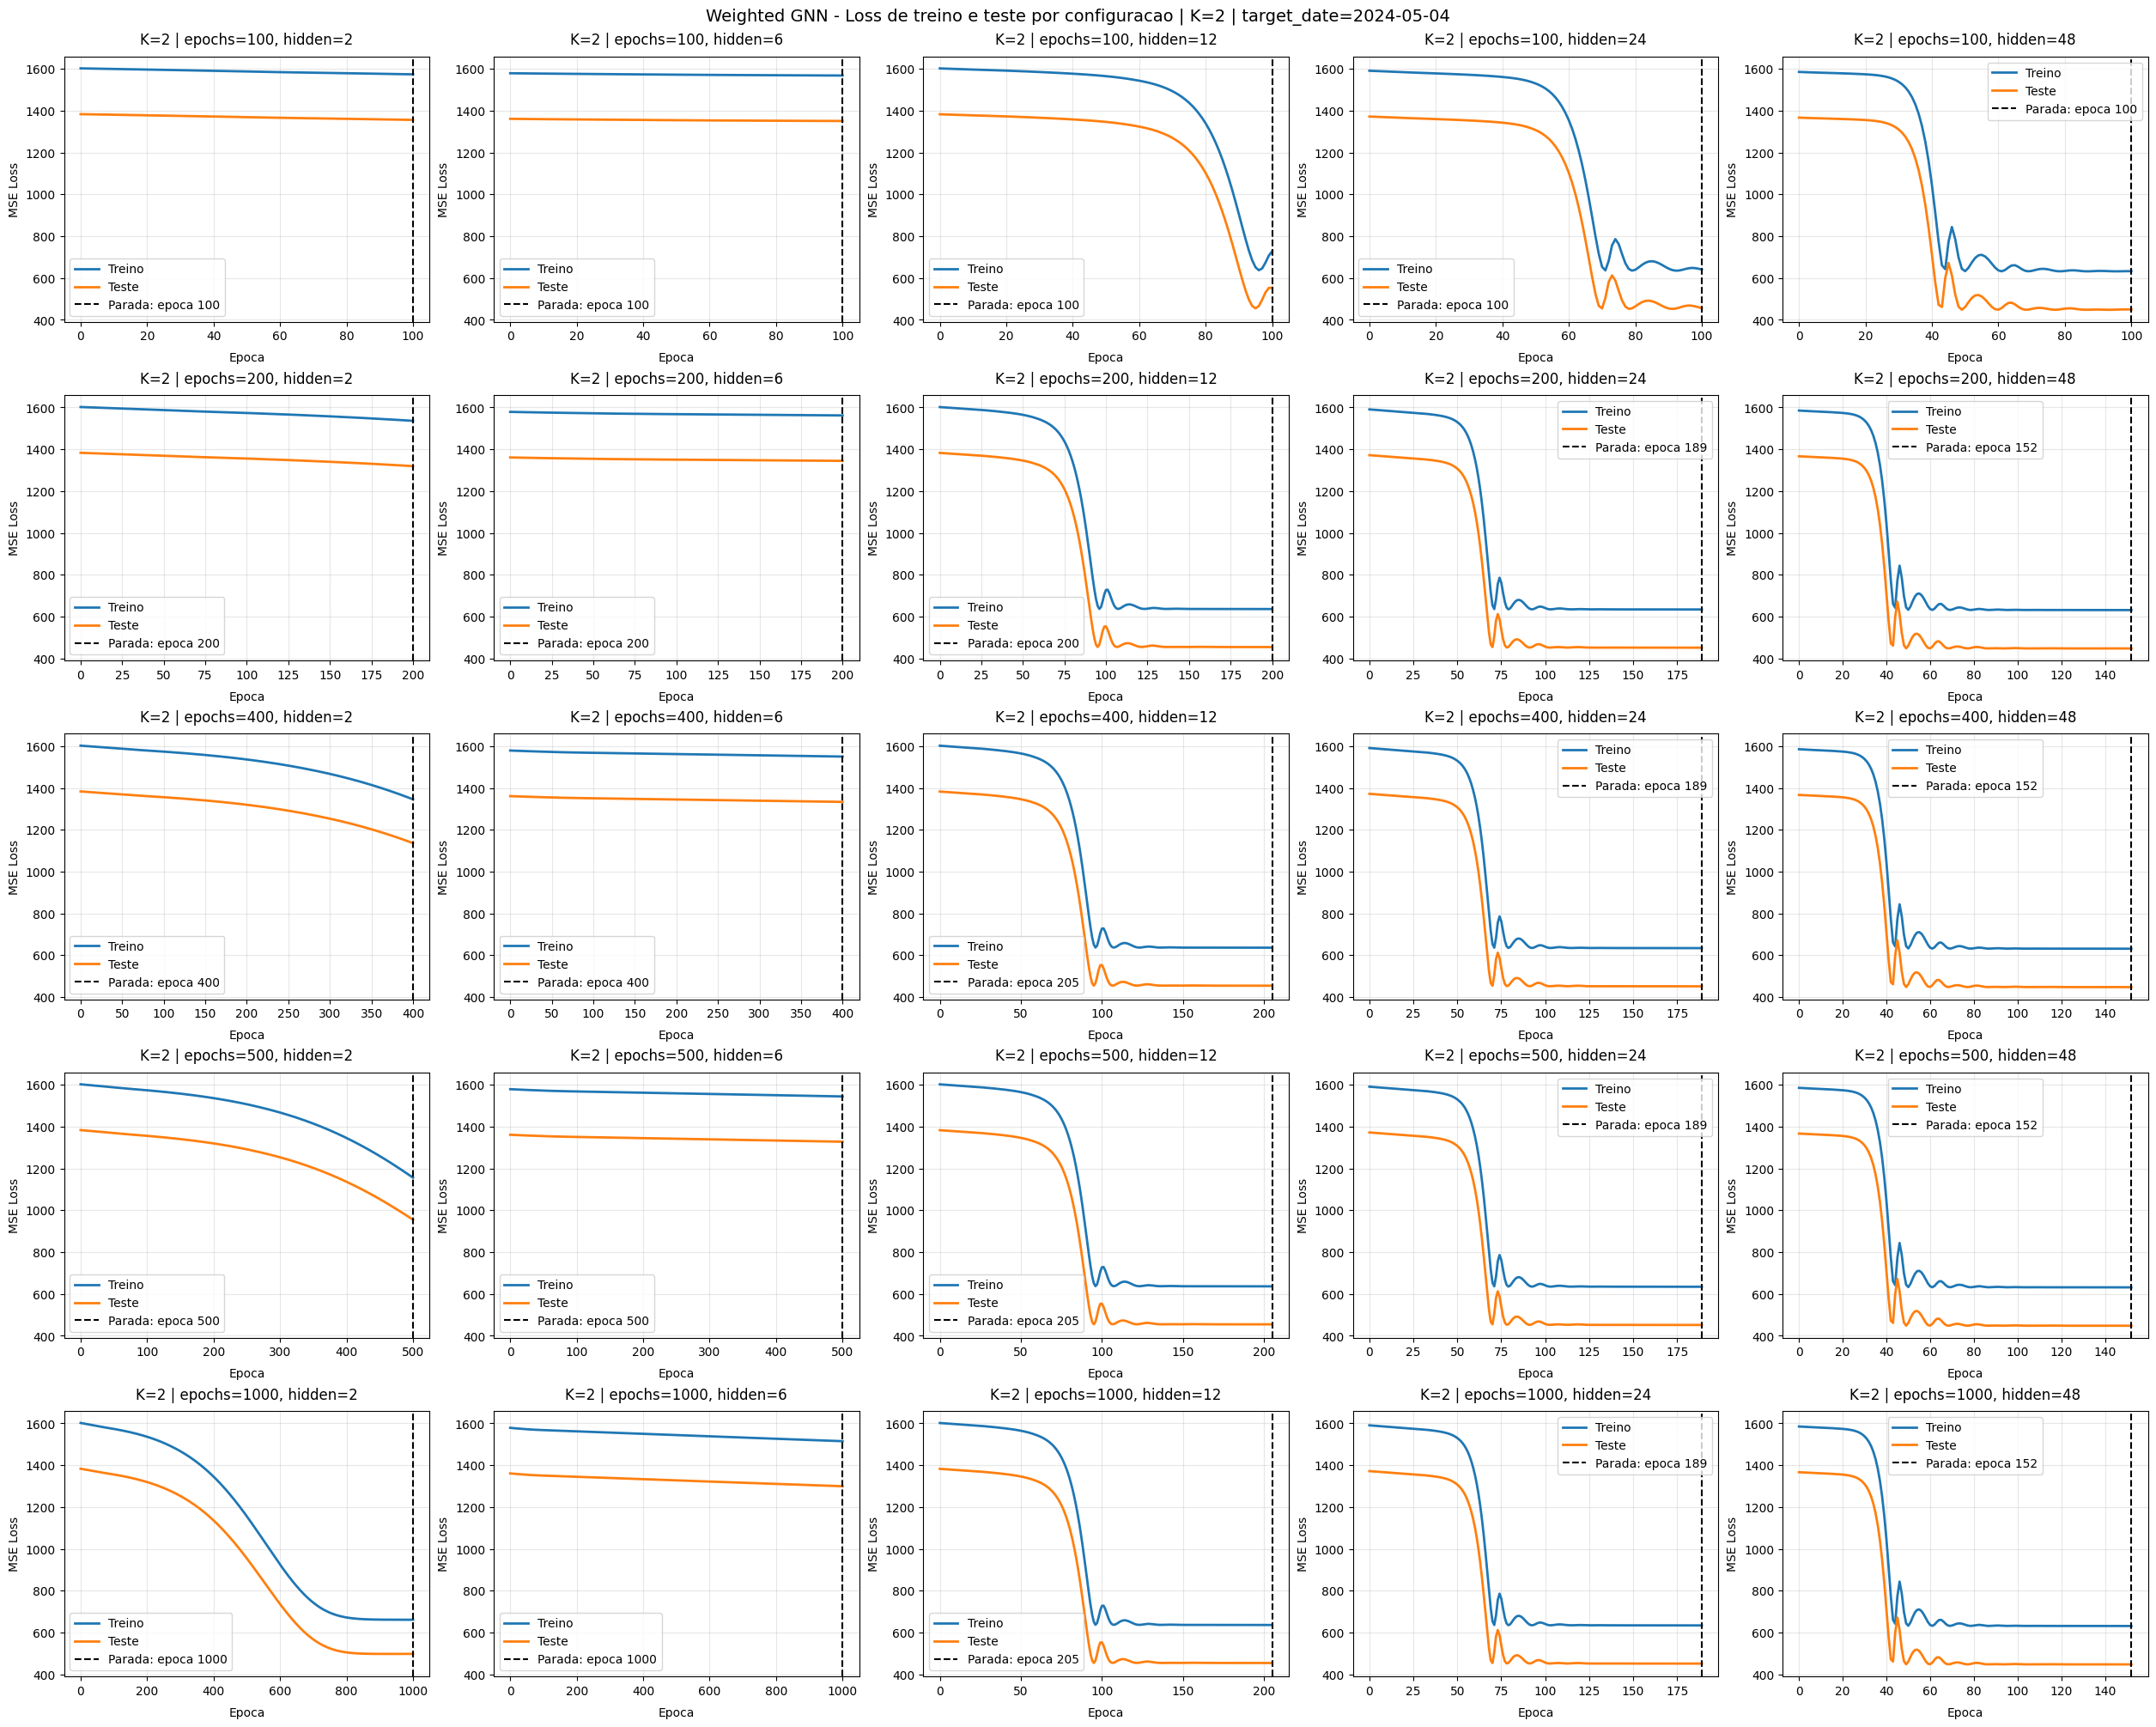


===== Gerando gráficos para K=3 =====
Grafico salvo em: ..\Graphics_WGNN\WeightedGNNGraphics-K3-HL12-D20240504.png


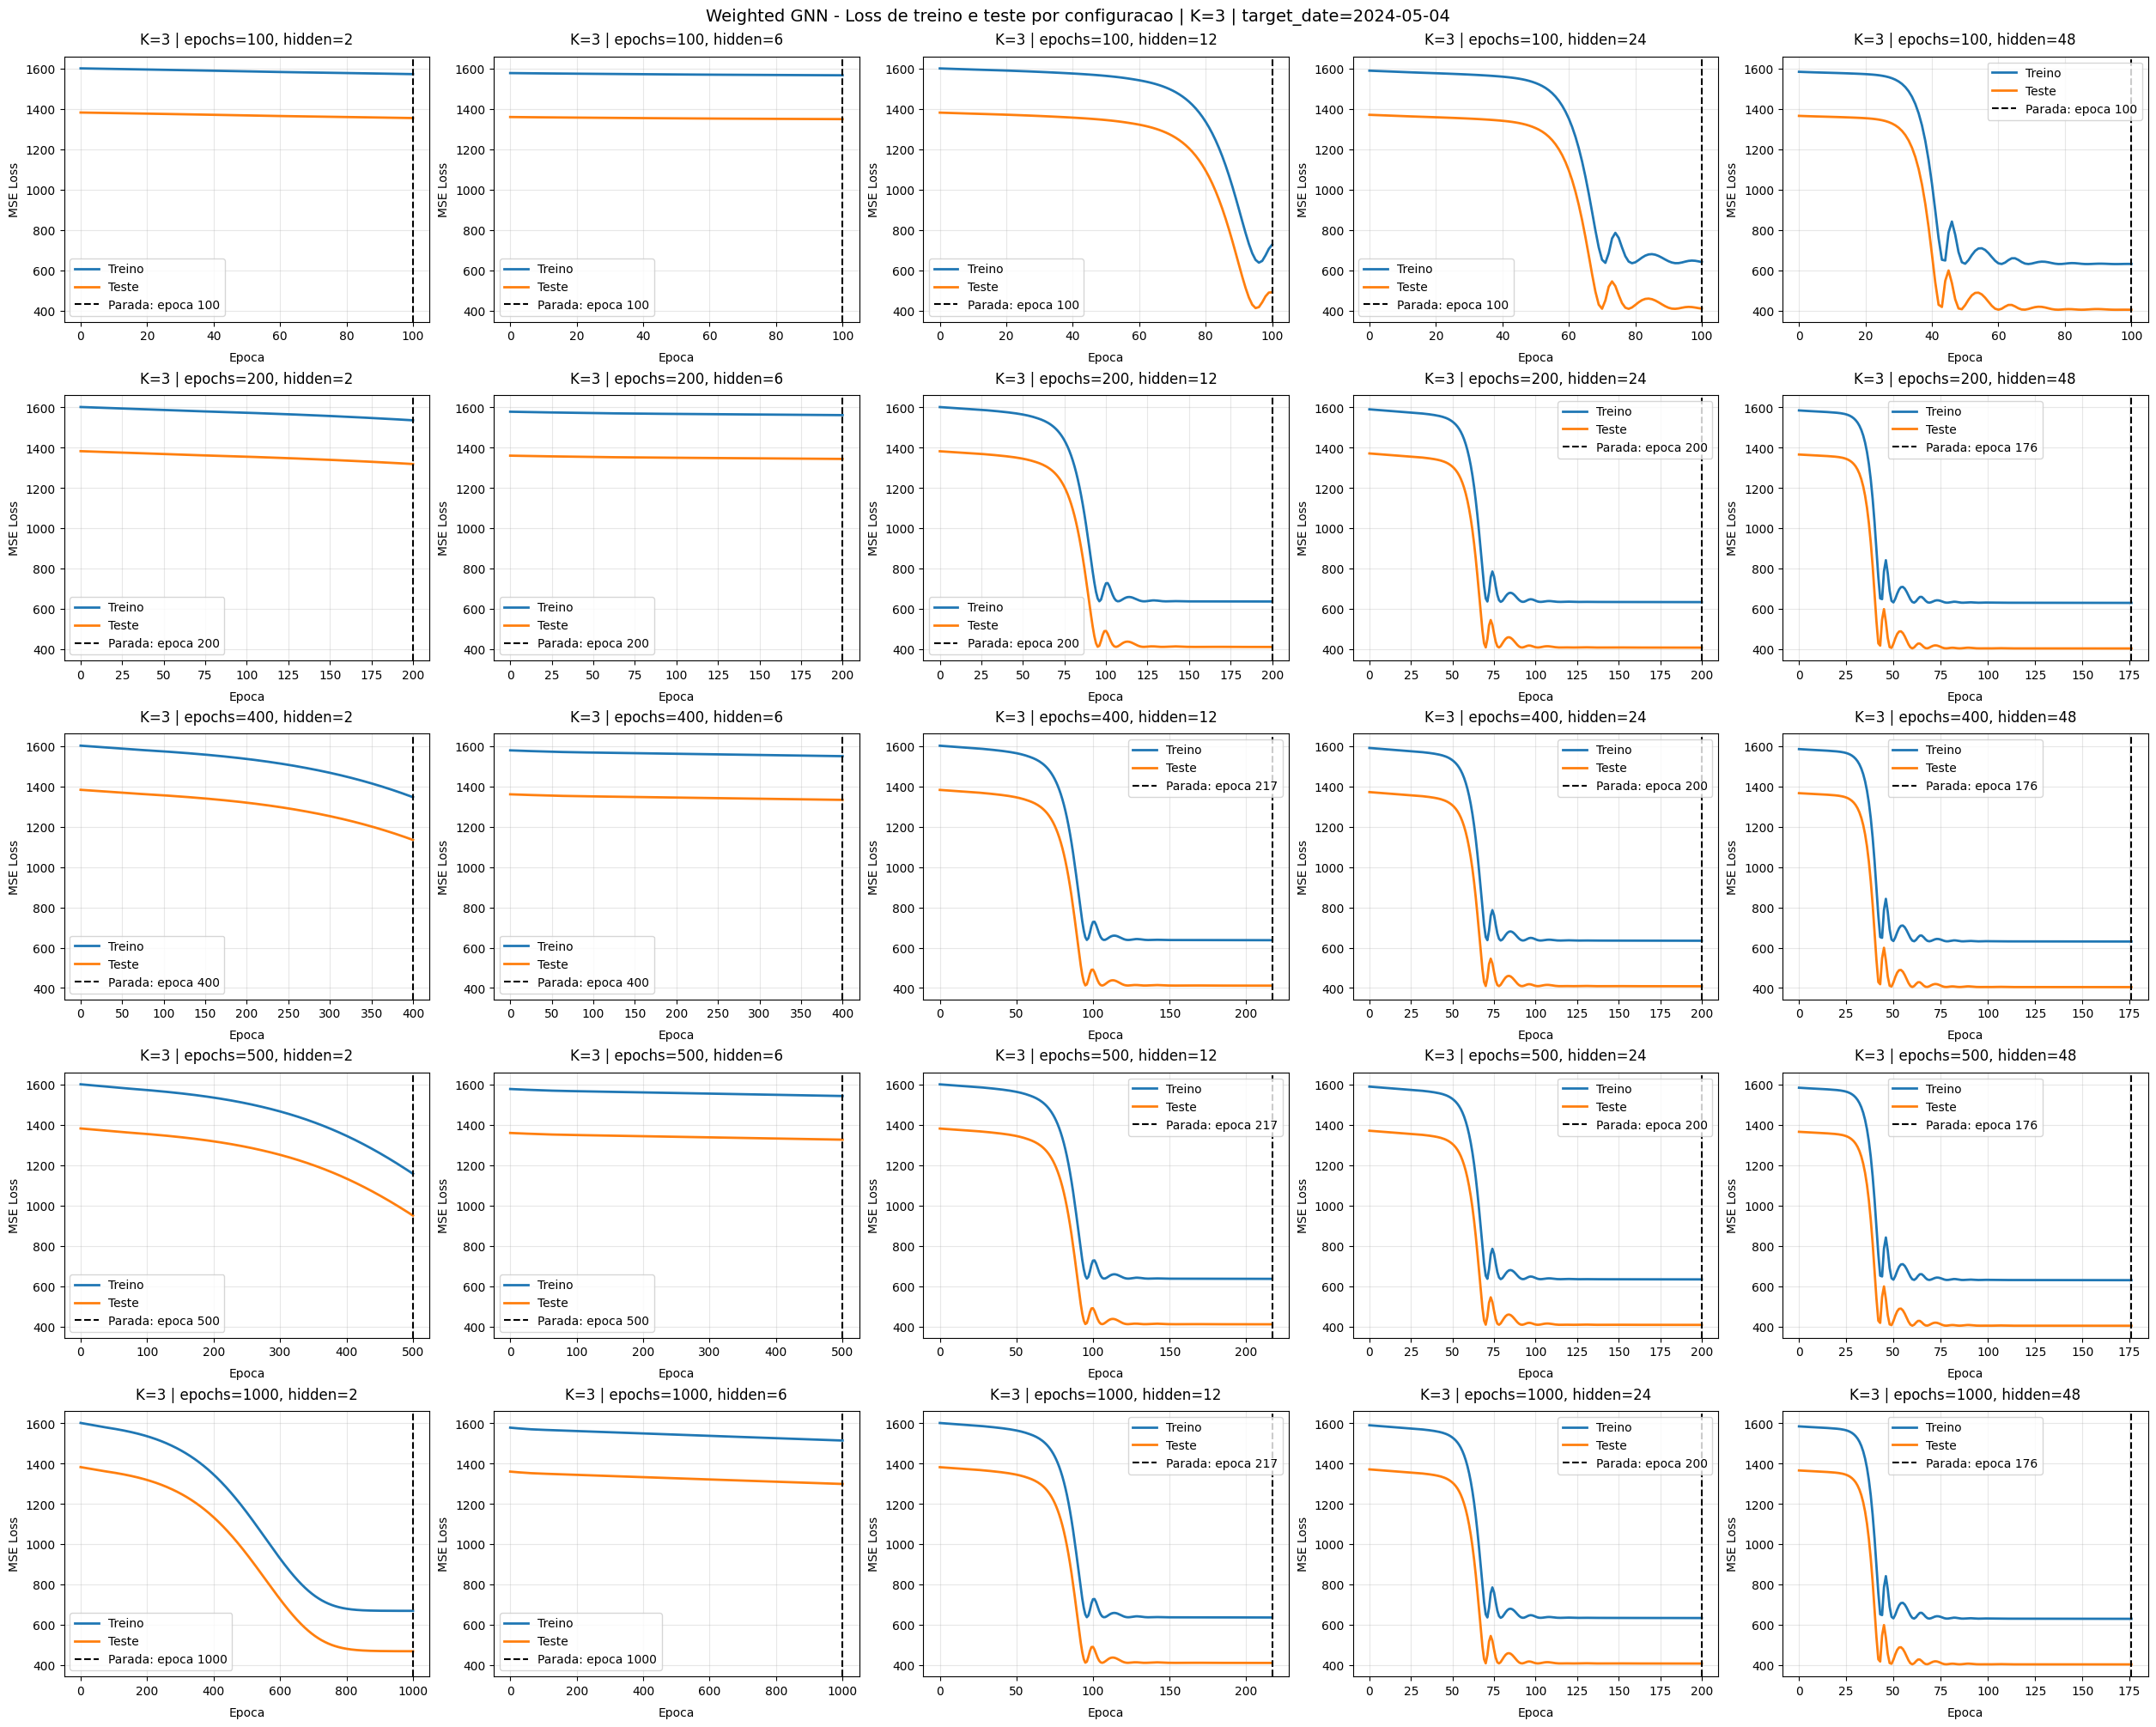


===== Gerando gráficos para K=61 =====
Grafico salvo em: ..\Graphics_WGNN\WeightedGNNGraphics-K61-HL12-D20240504.png


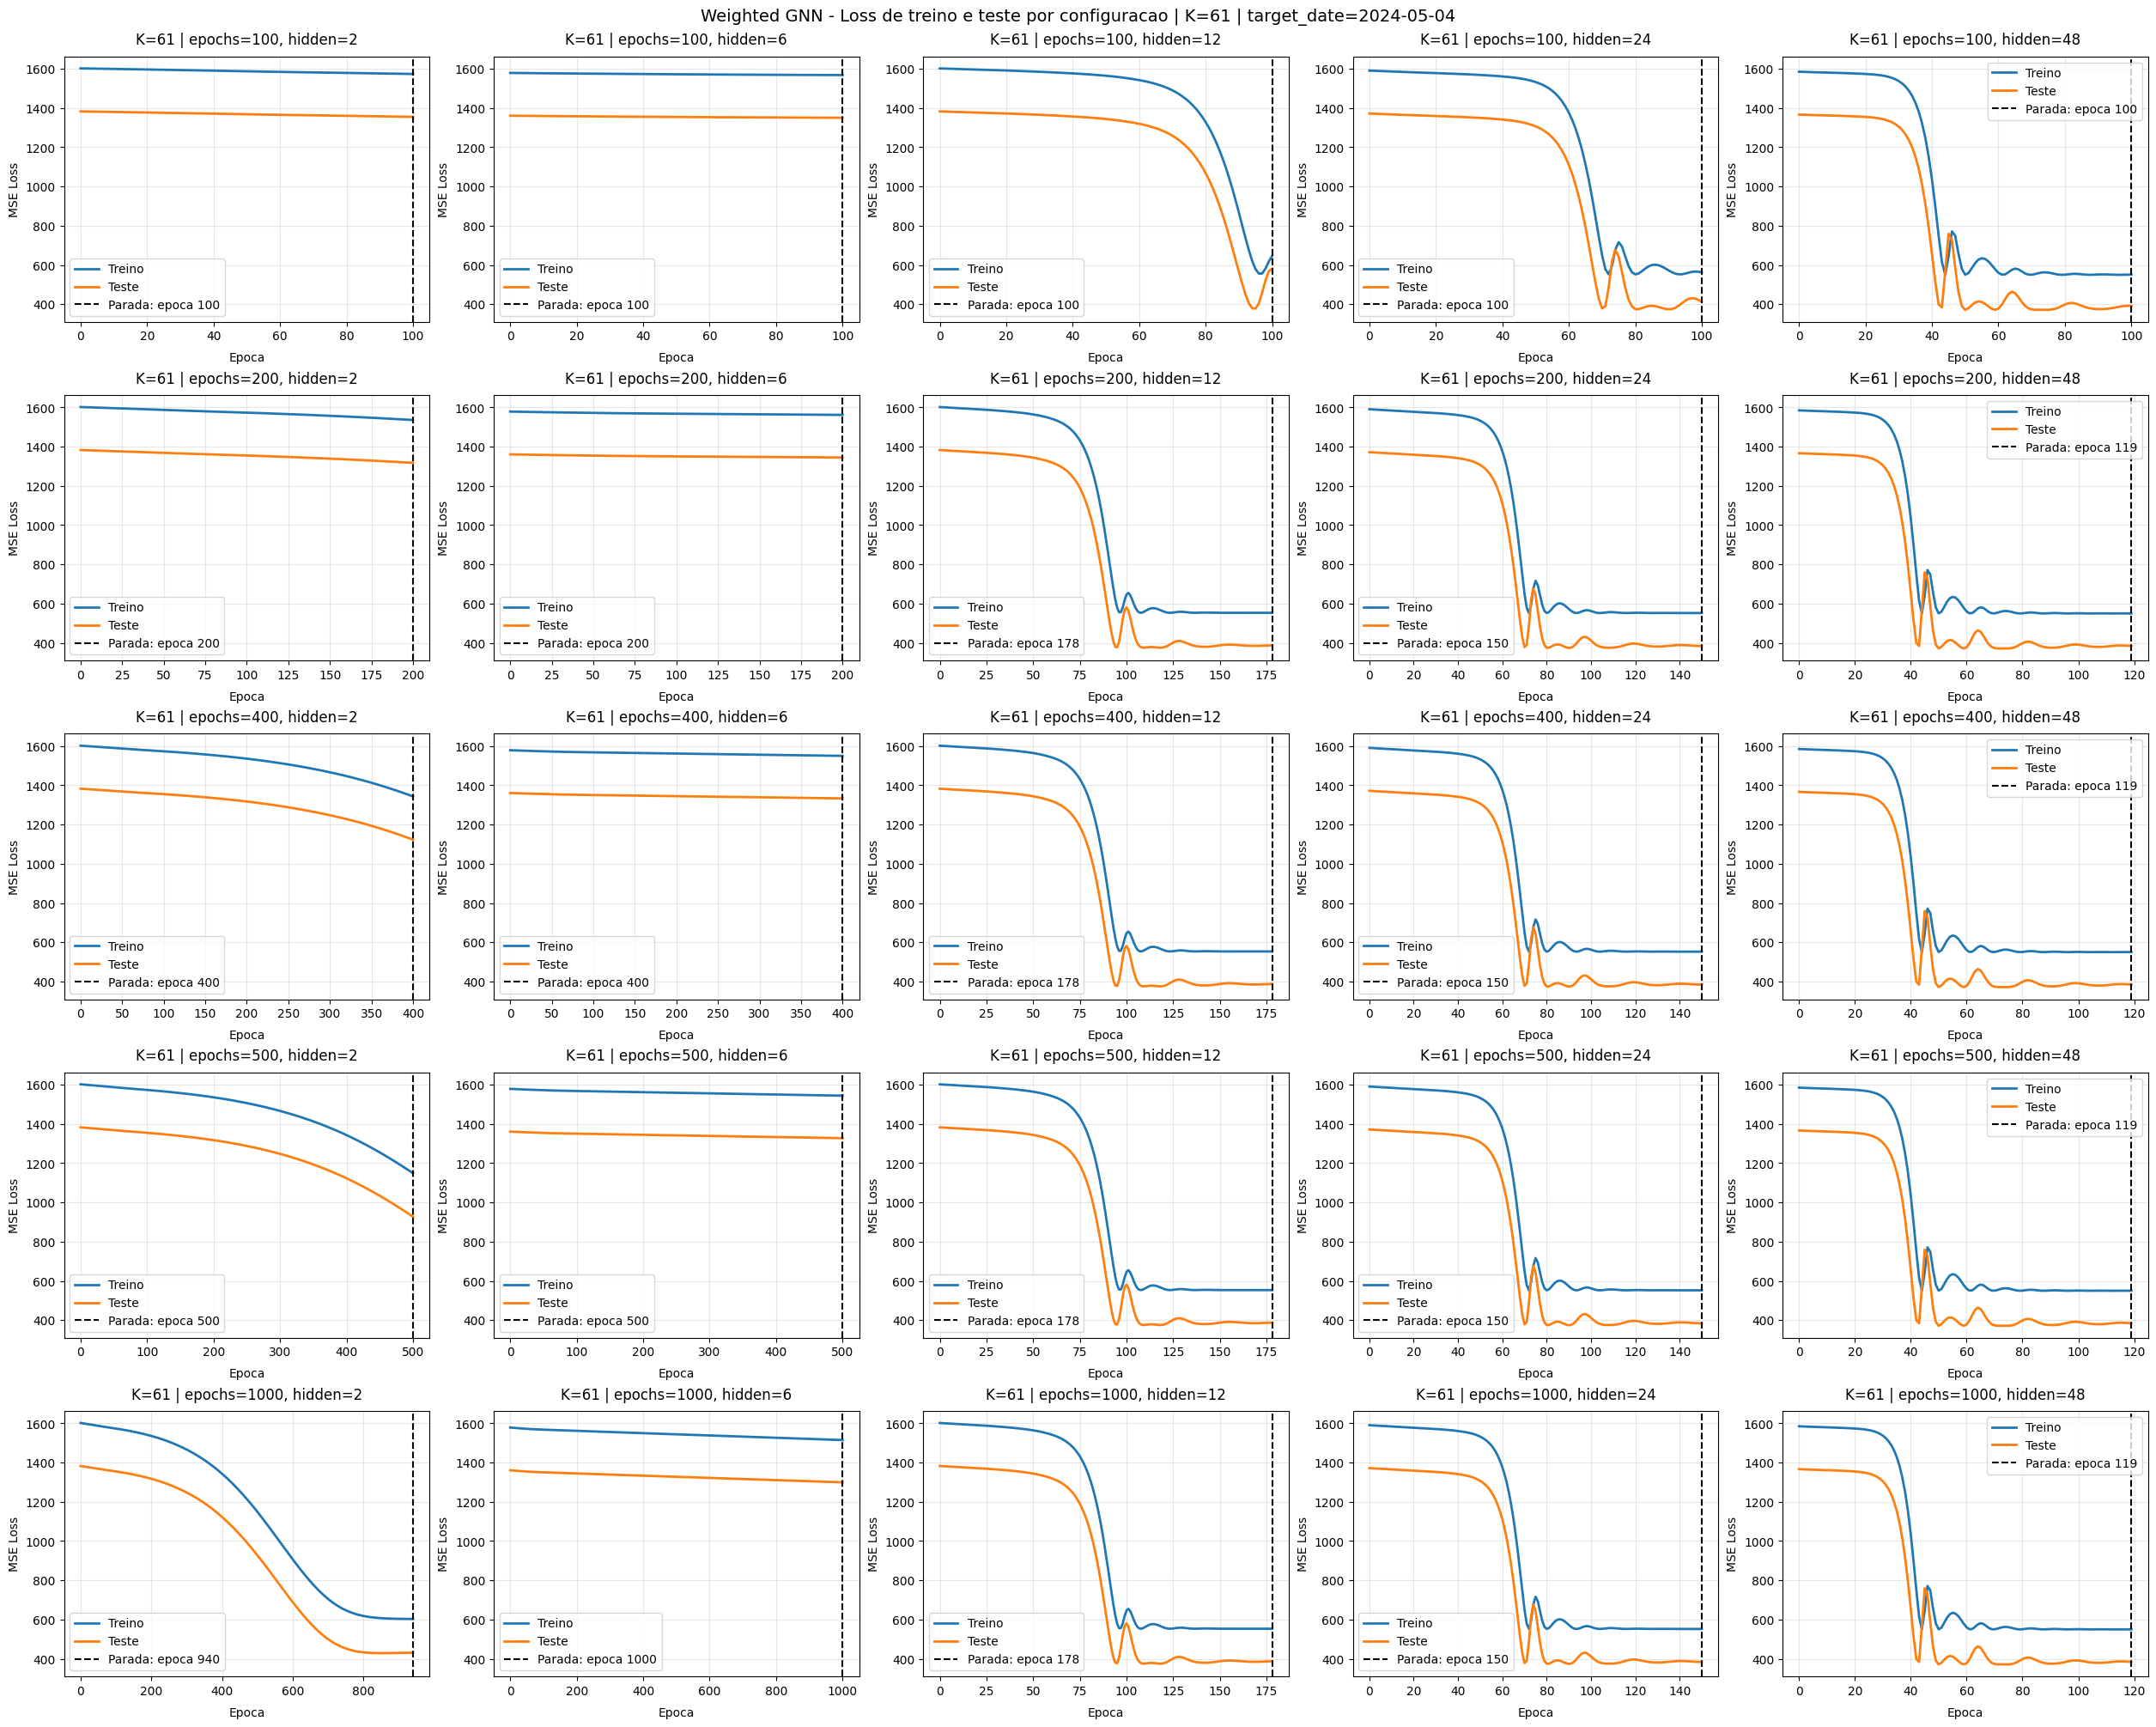

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

graphics_dir = Path("../Graphics_WGNN")
graphics_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")

for k_atual in k_grid:
    print(f"\n===== Gerando gráficos para K={k_atual} =====")

    n_linhas = len(epochs_grid)
    n_colunas = len(hidden_grid)

    todos_losses = []

    for ep in epochs_grid:
        for hd in hidden_grid:
            hist = historicos_weighted[(k_atual, ep, hd)]
            todos_losses.extend(hist["train_loss"])
            todos_losses.extend(hist["test_loss"])

    y_min = min(todos_losses)
    y_max = max(todos_losses)

    margem = 0.05 * (y_max - y_min)

    if margem == 0:
        margem = 1

    y_min -= margem
    y_max += margem

    fig, axes = plt.subplots(
        n_linhas,
        n_colunas,
        figsize=(5 * n_colunas, 4 * n_linhas),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(n_linhas, n_colunas)

    for i, ep in enumerate(epochs_grid):
        for j, hd in enumerate(hidden_grid):
            ax = axes[i, j]

            hist = historicos_weighted[(k_atual, ep, hd)]
            epocas = range(len(hist["train_loss"]))

            ax.plot(epocas, hist["train_loss"], label="Treino", color="tab:blue", linewidth=2)
            ax.plot(epocas, hist["test_loss"], label="Teste", color="tab:orange", linewidth=2)

            stop_epoch = paradas_weighted[(k_atual, ep, hd)]

            ax.axvline(
                stop_epoch,
                color="black",
                linestyle="--",
                linewidth=1.5,
                label=f"Parada: epoca {stop_epoch}",
            )

            ax.set_title(f"K={k_atual} | epochs={ep}, hidden={hd}", pad=10)
            ax.set_xlabel("Epoca", labelpad=8)
            ax.set_ylabel("MSE Loss")
            ax.set_ylim(y_min, y_max)
            ax.tick_params(axis="y", labelleft=True)
            ax.grid(alpha=0.3)
            ax.legend(loc="best")

    fig.suptitle(
        f"Weighted GNN - Loss de treino e teste por configuracao | K={k_atual} | target_date={target_date}",
        fontsize=14,
    )

    nome_imagem = f"WeightedGNNGraphics-K{k_atual}-HL{n_hidden_layers}-D{target_date_file}.png"
    output_path = graphics_dir / nome_imagem

    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    print(f"Grafico salvo em: {output_path}")

    plt.show()

In [ ]:
# =====================================================
# PDF final: uma tabela de 25 linhas para cada k,
# seguida pelos graficos finais de cada k.
# Execute esta celula depois das duas celulas anteriores.
# =====================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, FileLink


# Localiza a raiz do projeto tanto quando o notebook e aberto em Notebooks/
# quanto quando o servidor Jupyter e iniciado na raiz do repositorio.
project_dir = Path.cwd()
if project_dir.name.lower() == "notebooks":
    project_dir = project_dir.parent

pdf_dir = project_dir / "PDFs"
graphics_dir_pdf = project_dir / "Graphics_WGNN"
pdf_dir.mkdir(parents=True, exist_ok=True)

pdf_path = pdf_dir / (
    f"WeightedGNN-ResultadosFinais-HL{n_hidden_layers}-D{target_date_file}.pdf"
)

# As grades definidas acima devem produzir exatamente 25 resultados por k.
expected_rows = len(epochs_grid) * len(hidden_grid)
if expected_rows != 25:
    raise ValueError(
        f"A grade atual produz {expected_rows} linhas por k; eram esperadas 25."
    )

# Ordem e rotulos usados nas tabelas do PDF.
pdf_columns = [
    "epochs", "hidden", "n_hidden_layers", "best_epoch", "stop_epoch",
    "loss_train", "loss_val", "loss_test", "pred", "true", "k",
]
pdf_headers = {
    "epochs": "Epocas",
    "hidden": "Hidden",
    "n_hidden_layers": "Camadas",
    "best_epoch": "Melhor epoca",
    "stop_epoch": "Epoca parada",
    "loss_train": "Loss treino",
    "loss_val": "Loss validacao",
    "loss_test": "Loss teste",
    "pred": "Predicao",
    "true": "Real",
    "k": "k",
}
integer_columns = {
    "epochs", "hidden", "n_hidden_layers", "best_epoch", "stop_epoch", "k"
}


def prepare_pdf_table(df, k_value):
    """Valida, ordena e formata a tabela de um valor de k."""
    missing_columns = [column for column in pdf_columns if column not in df.columns]
    if missing_columns:
        raise KeyError(f"Colunas ausentes na tabela de k={k_value}: {missing_columns}")

    table_df = (
        df.loc[:, pdf_columns]
        .sort_values(["epochs", "hidden"])
        .reset_index(drop=True)
        .copy()
    )

    if len(table_df) != expected_rows:
        raise ValueError(
            f"A tabela de k={k_value} tem {len(table_df)} linhas; "
            f"eram esperadas {expected_rows}."
        )

    for column in pdf_columns:
        if column in integer_columns:
            table_df[column] = table_df[column].map(lambda value: f"{int(value)}")
        else:
            table_df[column] = table_df[column].map(lambda value: f"{float(value):.6f}")

    return table_df.rename(columns=pdf_headers)


def add_table_page(pdf, table_df, k_value, page_number):
    """Adiciona ao PDF uma pagina A3 horizontal com as 25 linhas."""
    fig, ax = plt.subplots(figsize=(16.54, 11.69))  # A3 horizontal
    ax.axis("off")

    fig.suptitle(
        f"Weighted GNN - Resultados finais para k={k_value}",
        fontsize=18,
        fontweight="bold",
        y=0.965,
    )
    ax.set_title(
        f"{len(table_df)} configuracoes | Data alvo: {target_date}",
        fontsize=11,
        pad=12,
    )

    # Distribui a largura conforme o tamanho do cabecalho e do conteudo.
    width_weights = []
    for column in table_df.columns:
        max_text = max(len(str(column)), table_df[column].astype(str).str.len().max())
        width_weights.append(max_text + 2)
    column_widths = np.asarray(width_weights, dtype=float)
    column_widths = 0.98 * column_widths / column_widths.sum()

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=column_widths,
        bbox=[0.01, 0.055, 0.98, 0.84],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7.2)

    for (row, _column), cell in table.get_celld().items():
        cell.set_edgecolor("#B8C2CC")
        cell.set_linewidth(0.45)
        if row == 0:
            cell.set_facecolor("#1F4E78")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#EAF2F8")
        else:
            cell.set_facecolor("white")

    fig.text(
        0.5, 0.025, f"Pagina {page_number}",
        ha="center", va="center", fontsize=9, color="#4A5568",
    )
    pdf.savefig(fig)
    plt.close(fig)


def add_graph_page(pdf, image_path, k_value, page_number):
    """Adiciona um grafico final, reduzindo a imagem apenas para controlar a memoria."""
    with Image.open(image_path) as source_image:
        graph_image = source_image.convert("RGB")
        graph_image.thumbnail((3600, 3000), Image.Resampling.LANCZOS)

        image_width, image_height = graph_image.size
        page_width = 16.54
        page_height = page_width * image_height / image_width + 1.0

        fig = plt.figure(figsize=(page_width, page_height))
        ax = fig.add_axes([0.015, 0.045, 0.97, 0.90])
        ax.imshow(graph_image)
        ax.axis("off")

        fig.suptitle(
            f"Weighted GNN - Graficos finais para k={k_value}",
            fontsize=18,
            fontweight="bold",
            y=0.985,
        )
        fig.text(
            0.5, 0.018, f"Pagina {page_number}",
            ha="center", va="center", fontsize=9, color="#4A5568",
        )
        pdf.savefig(fig)
        plt.close(fig)


# Prepara e valida todas as entradas antes de iniciar a gravacao do PDF.
tables_for_pdf = {}
graph_paths_for_pdf = {}

for k_value in k_grid:
    if k_value not in dfs_weighted_por_k:
        raise KeyError(f"Nao foi encontrada a tabela final de k={k_value}.")

    tables_for_pdf[k_value] = prepare_pdf_table(
        dfs_weighted_por_k[k_value], k_value
    )

    graph_path = graphics_dir_pdf / (
        f"WeightedGNNGraphics-K{k_value}-HL{n_hidden_layers}-D{target_date_file}.png"
    )
    if not graph_path.exists():
        raise FileNotFoundError(
            f"Grafico de k={k_value} nao encontrado: {graph_path}. "
            "Execute primeiro a celula que gera os graficos."
        )
    graph_paths_for_pdf[k_value] = graph_path


with PdfPages(
    pdf_path,
    metadata={
        "Title": "Weighted GNN - Resultados finais",
        "Author": "WeightedEdges.ipynb",
        "Subject": "Tabelas e graficos finais por valor de k",
    },
) as pdf:
    page_number = 1

    # Primeiro entram todas as tabelas, uma pagina para cada k.
    for k_value in k_grid:
        add_table_page(pdf, tables_for_pdf[k_value], k_value, page_number)
        page_number += 1

    # Depois entram todos os graficos, um por pagina e na mesma ordem dos k.
    for k_value in k_grid:
        add_graph_page(
            pdf, graph_paths_for_pdf[k_value], k_value, page_number
        )
        page_number += 1

print(f"PDF final salvo em: {pdf_path.resolve()}")
display(FileLink(str(pdf_path)))

# Tabela por data para os nós de validação e teste

Esta seção reproduz, para a **Weighted GNN**, a estrutura da última tabela de `gnn_gcn_compact.ipynb`: o modelo é retreinado para cada data e a tabela apresenta os valores reais, as predições e os erros de cada nó de validação e teste.

In [ ]:
# Configuração usada nas tabelas por data.
epochs_tabela = 200
hidden_tabela = 24
n_hidden_layers_tabela = 6
k_tabela = 3


def build_day_data_weighted(data):
    """Monta as features e o alvo da Weighted GNN para uma data."""
    data_timestamp = pd.to_datetime(data)
    inicio_timestamp = pd.to_datetime(start_date)
    fim_timestamp = pd.to_datetime(end_date)

    if not inicio_timestamp <= data_timestamp <= fim_timestamp:
        raise ValueError(
            f"A data {data} está fora do intervalo "
            f"{start_date} a {end_date}."
        )

    t_idx_dia = (data_timestamp - inicio_timestamp).days

    X_dia = torch.stack(
        [
            X_vv[t_idx_dia, :, 0],
            X_t[t_idx_dia, :, 0],
        ],
        dim=-1,
    ).float()

    y_dia = X_tp[t_idx_dia, :, 0].float()
    return X_dia, y_dia


def build_weighted_graph_for_table(k):
    """Cria o grafo k-NN ponderado por exp(-distância)."""
    A_binaria = build_adjacency(
        coords,
        k=k,
        include_self=False,
    )

    coords_dia = torch.tensor(coords, dtype=torch.float32)
    distancias = torch.cdist(coords_dia, coords_dia, p=2)
    matriz_pesos = torch.exp(-distancias)

    mascara_arestas = torch.tensor(
        A_binaria,
        dtype=torch.bool,
    )
    mascara_arestas.fill_diagonal_(False)

    pesos_arestas = {
        (int(i), int(j)): float(matriz_pesos[i, j])
        for i, j in mascara_arestas.nonzero(as_tuple=False)
    }

    return make_weighted_adjacency_from_binary(
        A_base=A_binaria,
        edge_weights=pesos_arestas,
        default_edge_weight=1.0,
        self_loop_weight=1.0,
        symmetric=True,
        allow_new_edges=False,
    )


def gerar_tabela_weighted_por_dia(
    data,
    epochs=epochs_tabela,
    hidden=hidden_tabela,
    n_hidden_layers=n_hidden_layers_tabela,
    k=k_tabela,
    lr=1e-3,
    patience=60,
    min_delta=1e-4,
    seed=42,
):
    # 1) Dados do dia e grafo ponderado.
    X_dia, y_dia = build_day_data_weighted(data)
    _, A_norm_weighted_dia = build_weighted_graph_for_table(k)

    # 2) Reprodutibilidade.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 3) Modelo, otimizador e função de perda.
    modelo_dia = WeightedGNN(
        in_dim=X_dia.shape[1],
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers,
        out_dim=1,
    )

    otimizador_dia = torch.optim.Adam(
        modelo_dia.parameters(),
        lr=lr,
    )
    loss_fn_dia = nn.MSELoss(reduction="mean")

    melhor_loss_validacao = float("inf")
    melhor_estado = copy.deepcopy(modelo_dia.state_dict())
    melhor_epoca = 0
    contador_paciencia = 0

    # 4) Treinamento com early stopping pela validação.
    for epoca in range(epochs + 1):
        modelo_dia.train()
        otimizador_dia.zero_grad()

        y_pred_treino = modelo_dia(
            X_dia,
            A_norm_weighted_dia,
        )
        loss_treino = loss_fn_dia(
            y_pred_treino[mask_train],
            y_dia[mask_train],
        )

        loss_treino.backward()
        otimizador_dia.step()

        modelo_dia.eval()
        with torch.no_grad():
            y_pred_validacao = modelo_dia(
                X_dia,
                A_norm_weighted_dia,
            )
            loss_validacao = loss_fn_dia(
                y_pred_validacao[mask_val],
                y_dia[mask_val],
            ).item()

        if loss_validacao < melhor_loss_validacao - min_delta:
            melhor_loss_validacao = loss_validacao
            melhor_estado = copy.deepcopy(modelo_dia.state_dict())
            melhor_epoca = epoca
            contador_paciencia = 0
        else:
            contador_paciencia += 1

        if contador_paciencia >= patience:
            break

    # 5) Predições e losses do melhor estado do modelo.
    modelo_dia.load_state_dict(melhor_estado)
    modelo_dia.eval()

    with torch.no_grad():
        y_pred_dia = modelo_dia(
            X_dia,
            A_norm_weighted_dia,
        )

        loss_media_treino = loss_fn_dia(
            y_pred_dia[mask_train],
            y_dia[mask_train],
        ).item()
        loss_media_validacao = loss_fn_dia(
            y_pred_dia[mask_val],
            y_dia[mask_val],
        ).item()
        loss_media_teste = loss_fn_dia(
            y_pred_dia[mask_test],
            y_dia[mask_test],
        ).item()

    # 6) Linhas dos nós de validação e teste.
    mask_avaliacao = mask_val | mask_test
    indices_avaliacao = torch.where(mask_avaliacao)[0]
    indices_numpy = indices_avaliacao.detach().cpu().numpy()

    valores_reais = (
        y_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )
    valores_preditos = (
        y_pred_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )

    conjuntos = np.where(
        mask_val[indices_avaliacao].detach().cpu().numpy(),
        "Validação",
        "Teste",
    )

    tabela = pd.DataFrame({
        "Modelo": "Weighted GNN",
        "Data": data,
        "k": k,
        "Conjunto": conjuntos,
        "Nó": indices_numpy,
        "Estação": [estacoes[i] for i in indices_numpy],
        "Valor verdadeiro": valores_reais,
        "Valor predito": valores_preditos,
    })

    tabela["Erro (predito - verdadeiro)"] = (
        tabela["Valor predito"] - tabela["Valor verdadeiro"]
    )
    tabela["Erro absoluto"] = tabela[
        "Erro (predito - verdadeiro)"
    ].abs()
    tabela["Erro quadrático"] = tabela[
        "Erro (predito - verdadeiro)"
    ] ** 2

    ordem_conjuntos = pd.CategoricalDtype(
        categories=["Validação", "Teste"],
        ordered=True,
    )
    tabela["Conjunto"] = tabela["Conjunto"].astype(ordem_conjuntos)
    tabela = (
        tabela
        .sort_values(["Conjunto", "Nó"])
        .reset_index(drop=True)
    )

    tabela.attrs["melhor_epoca"] = melhor_epoca
    tabela.attrs["loss_media_treino"] = loss_media_treino
    tabela.attrs["loss_media_validacao"] = loss_media_validacao
    tabela.attrs["loss_media_teste"] = loss_media_teste
    return tabela


# Mesmas datas usadas na tabela final de gnn_gcn_compact.ipynb.
datas_avaliadas_weighted = [
    "2024-05-12",
    "2024-01-17",
    "2025-01-12",
    "2025-02-08",
]

tabelas_weighted_por_dia = {}

for data in datas_avaliadas_weighted:
    print(f"Treinando Weighted GNN para {data} (k={k_tabela})...")

    tabela_dia = gerar_tabela_weighted_por_dia(
        data=data,
        epochs=epochs_tabela,
        hidden=hidden_tabela,
        n_hidden_layers=n_hidden_layers_tabela,
        k=k_tabela,
        lr=1e-3,
        patience=60,
        min_delta=1e-4,
        seed=SEED,
    )

    tabelas_weighted_por_dia[data] = tabela_dia

    print(f"Melhor época: {tabela_dia.attrs['melhor_epoca']}")
    print(
        "Loss média de treino: "
        f"{tabela_dia.attrs['loss_media_treino']:.6f}"
    )
    print(
        "Loss média de validação: "
        f"{tabela_dia.attrs['loss_media_validacao']:.6f}"
    )
    print(
        "Loss média de teste: "
        f"{tabela_dia.attrs['loss_media_teste']:.6f}"
    )

    display(
        tabela_dia.style
        .format({
            "Valor verdadeiro": "{:.4f}",
            "Valor predito": "{:.4f}",
            "Erro (predito - verdadeiro)": "{:.4f}",
            "Erro absoluto": "{:.4f}",
            "Erro quadrático": "{:.4f}",
        })
        .set_caption(
            "Weighted GNN — nós de validação e teste — "
            f"{data} — k={k_tabela}"
        )
    )

In [ ]:
# Configuração usada nas tabelas por data.
epochs_tabela = 200
hidden_tabela = 24
n_hidden_layers_tabela = 6
k_tabela = 3


def build_day_data_weighted(data):
    """Monta as features e o alvo da Weighted GNN para uma data."""
    data_timestamp = pd.to_datetime(data)
    inicio_timestamp = pd.to_datetime(start_date)
    fim_timestamp = pd.to_datetime(end_date)

    if not inicio_timestamp <= data_timestamp <= fim_timestamp:
        raise ValueError(
            f"A data {data} está fora do intervalo "
            f"{start_date} a {end_date}."
        )

    t_idx_dia = (data_timestamp - inicio_timestamp).days

    X_dia = torch.stack(
        [
            X_vv[t_idx_dia, :, 0],
            X_t[t_idx_dia, :, 0],
        ],
        dim=-1,
    ).float()

    y_dia = X_tp[t_idx_dia, :, 0].float()
    return X_dia, y_dia


def build_weighted_graph_for_table(k):
    """Cria o grafo k-NN ponderado por exp(-distância)."""
    A_binaria = build_adjacency(
        coords,
        k=k,
        include_self=False,
    )

    coords_dia = torch.tensor(coords, dtype=torch.float32)
    distancias = torch.cdist(coords_dia, coords_dia, p=2)
    matriz_pesos = torch.exp(-distancias)

    mascara_arestas = torch.tensor(
        A_binaria,
        dtype=torch.bool,
    )
    mascara_arestas.fill_diagonal_(False)

    pesos_arestas = {
        (int(i), int(j)): float(matriz_pesos[i, j])
        for i, j in mascara_arestas.nonzero(as_tuple=False)
    }

    return make_weighted_adjacency_from_binary(
        A_base=A_binaria,
        edge_weights=pesos_arestas,
        default_edge_weight=1.0,
        self_loop_weight=1.0,
        symmetric=True,
        allow_new_edges=False,
    )


def gerar_tabela_weighted_por_dia(
    data,
    epochs=epochs_tabela,
    hidden=hidden_tabela,
    n_hidden_layers=n_hidden_layers_tabela,
    k=k_tabela,
    lr=1e-3,
    patience=60,
    min_delta=1e-4,
    seed=42,
):
    # 1) Dados do dia e grafo ponderado.
    X_dia, y_dia = build_day_data_weighted(data)
    _, A_norm_weighted_dia = build_weighted_graph_for_table(k)

    # 2) Reprodutibilidade.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 3) Modelo, otimizador e função de perda.
    modelo_dia = WeightedGNN(
        in_dim=X_dia.shape[1],
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers,
        out_dim=1,
    )

    otimizador_dia = torch.optim.Adam(
        modelo_dia.parameters(),
        lr=lr,
    )

    loss_fn_dia = nn.MSELoss(reduction="mean")

    melhor_loss_validacao = float("inf")
    melhor_estado = copy.deepcopy(modelo_dia.state_dict())
    melhor_epoca = 0
    contador_paciencia = 0
    historico_losses = {
        "treino": [],
        "validacao": [],
        "teste": [],
    }

    # 4) Treinamento com early stopping pela validação.
    for epoca in range(epochs + 1):
        modelo_dia.train()
        otimizador_dia.zero_grad()

        y_pred_treino = modelo_dia(
            X_dia,
            A_norm_weighted_dia,
        )

        loss_treino = loss_fn_dia(
            y_pred_treino[mask_train],
            y_dia[mask_train],
        )

        loss_treino.backward()
        otimizador_dia.step()

        modelo_dia.eval()

        with torch.no_grad():
            y_pred_validacao = modelo_dia(
                X_dia,
                A_norm_weighted_dia,
            )

            loss_validacao = loss_fn_dia(
                y_pred_validacao[mask_val],
                y_dia[mask_val],
            ).item()

            loss_teste = loss_fn_dia(
                y_pred_validacao[mask_test],
                y_dia[mask_test],
            ).item()

        historico_losses["treino"].append(loss_treino.item())
        historico_losses["validacao"].append(loss_validacao)
        historico_losses["teste"].append(loss_teste)

        if loss_validacao < melhor_loss_validacao - min_delta:
            melhor_loss_validacao = loss_validacao
            melhor_estado = copy.deepcopy(modelo_dia.state_dict())
            melhor_epoca = epoca
            contador_paciencia = 0
        else:
            contador_paciencia += 1

        if contador_paciencia >= patience:
            break

    # 5) Predições e losses do melhor estado do modelo.
    modelo_dia.load_state_dict(melhor_estado)
    modelo_dia.eval()

    with torch.no_grad():
        y_pred_dia = modelo_dia(
            X_dia,
            A_norm_weighted_dia,
        )

        loss_media_treino = loss_fn_dia(
            y_pred_dia[mask_train],
            y_dia[mask_train],
        ).item()

        loss_media_validacao = loss_fn_dia(
            y_pred_dia[mask_val],
            y_dia[mask_val],
        ).item()

        loss_media_teste = loss_fn_dia(
            y_pred_dia[mask_test],
            y_dia[mask_test],
        ).item()

    # 6) Linhas dos nós de validação e teste.
    mask_avaliacao = mask_val | mask_test
    indices_avaliacao = torch.where(mask_avaliacao)[0]
    indices_numpy = indices_avaliacao.detach().cpu().numpy()

    valores_reais = (
        y_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )

    valores_preditos = (
        y_pred_dia[mask_avaliacao]
        .detach()
        .cpu()
        .numpy()
    )

    conjuntos = np.where(
        mask_val[indices_avaliacao].detach().cpu().numpy(),
        "Validação",
        "Teste",
    )

    # 7) Construção da tabela.
    tabela = pd.DataFrame({
        "Modelo": "Weighted GNN",
        "Data": data,
        "k": k,
        "Conjunto": conjuntos,
        "Nó": indices_numpy,
        "Estação": [estacoes[i] for i in indices_numpy],
        "Valor verdadeiro": valores_reais,
        "Valor predito": valores_preditos,
    })

    tabela["Erro (predito - verdadeiro)"] = (
        tabela["Valor predito"]
        - tabela["Valor verdadeiro"]
    )

    tabela["Erro absoluto"] = tabela[
        "Erro (predito - verdadeiro)"
    ].abs()

    tabela["Erro quadrático"] = tabela[
        "Erro (predito - verdadeiro)"
    ] ** 2

    # Validação primeiro; teste depois.
    ordem_conjuntos = pd.CategoricalDtype(
        categories=["Validação", "Teste"],
        ordered=True,
    )

    tabela["Conjunto"] = tabela["Conjunto"].astype(
        ordem_conjuntos
    )

    tabela = (
        tabela
        .sort_values(["Conjunto", "Nó"])
        .reset_index(drop=True)
    )

    # Métricas adicionais armazenadas nos atributos do DataFrame.
    tabela.attrs["melhor_epoca"] = melhor_epoca
    tabela.attrs["loss_media_treino"] = loss_media_treino
    tabela.attrs["loss_media_validacao"] = loss_media_validacao
    tabela.attrs["loss_media_teste"] = loss_media_teste
    tabela.attrs["historico_losses"] = historico_losses

    return tabela


# Mesmas datas usadas na tabela final de gnn_gcn_compact.ipynb.
datas_avaliadas_weighted = [
    "2024-05-12",
    "2024-01-17",
    "2025-01-12",
    "2025-02-08",
]

# Cada DataFrame poderá ser acessado pela respectiva data.
tabelas_weighted_por_dia = {}

# Pasta dos gráficos de loss referentes ao nó 32.
no_loss = 32
graphics_dir_no32 = Path("../Graphics_WGNN")
graphics_dir_no32.mkdir(parents=True, exist_ok=True)


for data in datas_avaliadas_weighted:
    print(
        f"Treinando Weighted GNN para {data} "
        f"(k={k_tabela})..."
    )

    tabela_dia = gerar_tabela_weighted_por_dia(
        data=data,
        epochs=epochs_tabela,
        hidden=hidden_tabela,
        n_hidden_layers=n_hidden_layers_tabela,
        k=k_tabela,
        lr=1e-3,
        patience=60,
        min_delta=1e-4,
        seed=SEED,
    )

    tabelas_weighted_por_dia[data] = tabela_dia

    print(
        f"Melhor época: "
        f"{tabela_dia.attrs['melhor_epoca']}"
    )

    print(
        "Loss média de treino: "
        f"{tabela_dia.attrs['loss_media_treino']:.6f}"
    )

    print(
        "Loss média de validação: "
        f"{tabela_dia.attrs['loss_media_validacao']:.6f}"
    )

    print(
        "Loss média de teste: "
        f"{tabela_dia.attrs['loss_media_teste']:.6f}"
    )

    display(
        tabela_dia.style
        .format({
            "Valor verdadeiro": "{:.4f}",
            "Valor predito": "{:.4f}",
            "Erro (predito - verdadeiro)": "{:.4f}",
            "Erro absoluto": "{:.4f}",
            "Erro quadrático": "{:.4f}",
        })
        .set_caption(
            "Weighted GNN — nós de validação e teste — "
            f"{data} — k={k_tabela}"
        )
    )

    # Curvas de treino, validação e teste do modelo para o nó-alvo 32.
    historico = tabela_dia.attrs["historico_losses"]
    epocas_executadas = range(len(historico["treino"]))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        epocas_executadas,
        historico["treino"],
        label="Treino",
        color="tab:blue",
        linewidth=2,
    )
    ax.plot(
        epocas_executadas,
        historico["validacao"],
        label="Validação",
        color="tab:green",
        linewidth=2,
    )
    ax.plot(
        epocas_executadas,
        historico["teste"],
        label="Teste",
        color="tab:orange",
        linewidth=2,
    )
    ax.axvline(
        tabela_dia.attrs["melhor_epoca"],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Melhor época: {tabela_dia.attrs['melhor_epoca']}",
    )
    ax.set_title(
        f"Weighted GNN — curvas de loss — nó {no_loss} — {data}"
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE Loss")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    data_arquivo = data.replace("-", "")
    caminho_grafico = graphics_dir_no32 / (
        f"WeightedGNN-Loss-No{no_loss}-D{data_arquivo}.png"
    )
    fig.savefig(caminho_grafico, dpi=300, bbox_inches="tight")
    print(f"Gráfico de loss do nó {no_loss} salvo em: {caminho_grafico}")
    plt.show()